In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task 1 — Inspect the Dataset


In [2]:
from pathlib import Path
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
dataset_path = "/content/drive/MyDrive/m6-04/data/DATA_CLEAN"
img_dir = os.path.join(dataset_path, "images")
lbl_dir = os.path.join(dataset_path, "labels")

imgs = os.listdir(img_dir)
lbls = os.listdir(lbl_dir)

print(f"Images: {len(imgs)}")
print(f"Labels: {len(lbls)}")

Images: 3442
Labels: 3442


In [4]:
counts = {}
for f in lbls:
    with open(os.path.join(lbl_dir, f), 'r') as file:
        for line in file:
            cls = line.split()[0]
            counts[cls] = counts.get(cls, 0) + 1

df = pd.DataFrame(list(counts.items()), columns=['Class ID', 'Count'])
print(df)

  Class ID  Count
0        0   4029


In [5]:
import cv2
sample_imgs = random.sample(imgs, 100)
widths, heights = [], []

for img_name in sample_imgs:
    img = cv2.imread(os.path.join(img_dir, img_name))
    h, w, _ = img.shape
    widths.append(w)
    heights.append(h)

print(f"Min W/H: {min(widths)}, {min(heights)}")
print(f"Max W/H: {max(widths)}, {max(heights)}")
print(f"Mean W/H: {sum(widths)/100}, {sum(heights)/100}")

Min W/H: 640, 640
Max W/H: 5184, 3456
Mean W/H: 2521.37, 1923.25


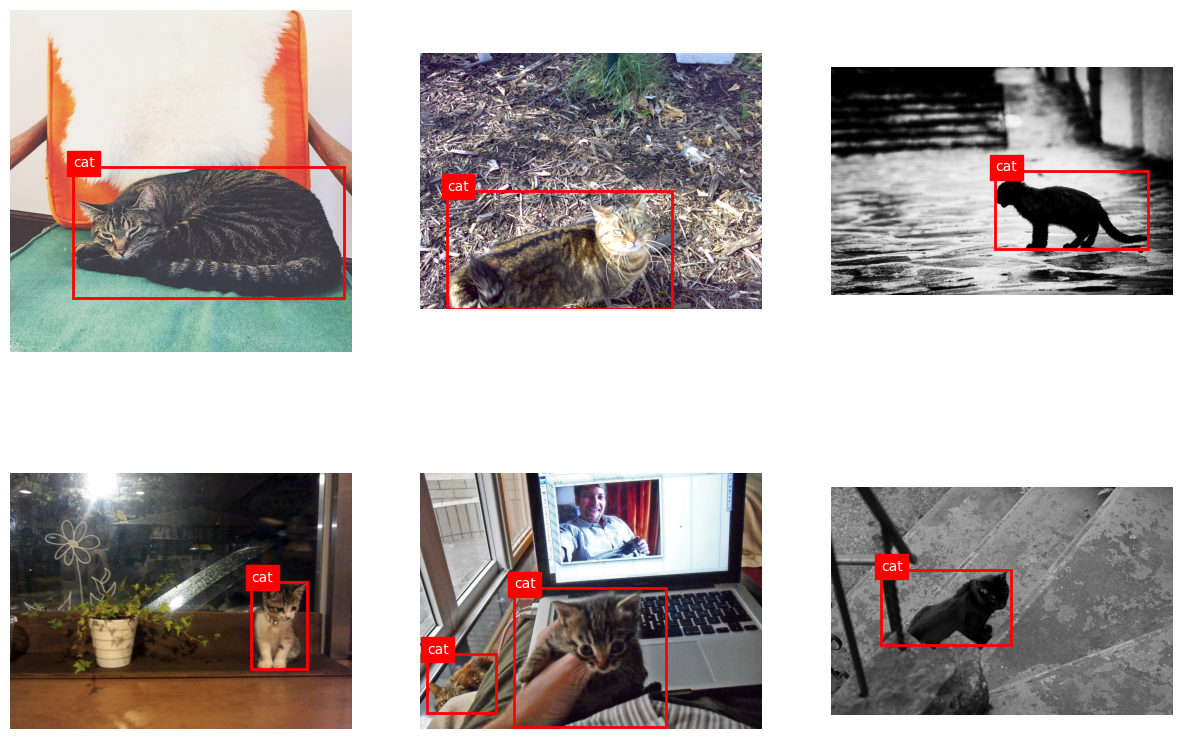

In [6]:
sample_6 = random.sample(imgs, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, img_name in enumerate(sample_6):
    img = cv2.imread(os.path.join(img_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    ax = axes[i//3, i%3]
    ax.imshow(img)

    txt_name = img_name.rsplit('.', 1)[0] + '.txt'
    with open(os.path.join(lbl_dir, txt_name), 'r') as f:
        for line in f:
            c, cx, cy, bw, bh = map(float, line.split())
            rect = patches.Rectangle(((cx-bw/2)*w, (cy-bh/2)*h), bw*w, bh*h,
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            ax.text((cx-bw/2)*w, (cy-bh/2)*h, 'cat', color='white', backgroundcolor='red')
    ax.axis('off')

plt.show()

## Dataset Pair Check
All images and labels were checked.
Every image has a matching label file and every label file has a matching image.
This means the dataset structure is correct and ready for training.

# Task 2 — Build Train / Val / Test Splits

In [8]:
all_imgs = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

random.seed(42)
random.shuffle(all_imgs)

t_idx = int(0.7 * len(all_imgs))
v_idx = int(0.85 * len(all_imgs))

train_list = all_imgs[:t_idx]
val_list = all_imgs[t_idx:v_idx]
test_list = all_imgs[v_idx:]

# Define filenames
files = {
    'train.txt': train_list,
    'val.txt': val_list,
    'test.txt': test_list
}

output_drive_path = "/content/drive/MyDrive/m6-04"

for filename, path_list in files.items():
    # 1. Local /content/ for YOLO training
    with open(f'/content/{filename}', 'w') as f:
        for path in path_list:
            f.write(path + '\n')

    # 2. Drive path for permanent storage and GitHub upload
    with open(os.path.join(output_drive_path, filename), 'w') as f:
        for path in path_list:
            f.write(path + '\n')

print(f"Files created in /content/ and saved to {output_drive_path}")

Files created in /content/ and saved to /content/drive/MyDrive/m6-04


In [10]:
import os
import yaml
data_yaml_content = {
    'path': dataset_path,
    'train': 'train.txt',
    'val': 'val.txt',
    'test': 'test.txt',
    'names': {0: 'cat'}
}

with open(os.path.join(dataset_path, 'data.yaml'), 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

## Train Validation Test Split

The dataset was shuffled using a fixed random seed.

The images were split into:
- 70% training
- 15% validation
- 15% testing

Three text files were created:
- train.txt
- val.txt
- test.txt

These files contain image paths used by YOLO26 during training and evaluation.

# Task 3 — Pick a YOLO26 Variant and Train It

In [1]:
!pip install ultralytics

The dataset contains ~3,442 images which is large enough that yolo26n might underfit, but small enough that yolo26m adds little benefit at extra cost. Training was done on a Colab T4 GPU where yolo26s fits comfortably in one session. 

In [12]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

results = model.train(
    data="/content/drive/MyDrive/m6-04/data/DATA_CLEAN/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/m6-04/runs",
    name="cats_v1",
    seed=42
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/m6-04/data/DATA_CLEAN/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015

### Task 3 — Training Results (Validation Set)

| Metric                  | Value  |
|-------------------------|--------|
| Best mAP@0.5 (val)      | 0.927 |
| Best mAP@0.5:0.95 (val) | 0.721 |
| Best epoch              | 28     |

The best validation mAP was reached at epoch 28 — the very last epoch — which means
the model had not fully converged and would likely improve with more epochs.
There are no visible signs of overfitting: the validation mAP continued to improve
until the end of training without plateauing or dropping.
In hindsight, `yolo26s` was the right choice — it trained efficiently on the T4 GPU
and achieved strong results without overfitting on this 3,442-image single-class dataset.

# Task 4 — Evaluate on the Test Set

In [13]:
metrics = model.val(data="/content/drive/MyDrive/m6-04/data/DATA_CLEAN/data.yaml", split="test")

print("--- Test Set Metrics ---")
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Mean Precision: {metrics.box.mp:.4f}")
print(f"Mean Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.0 ms, read: 1.0±0.6 MB/s, size: 614.0 KB)
val: Scanning /content/drive/MyDrive/m6-04/data/DATA_CLEAN/labels... 517 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 517/517 1.0s/it 8:57
val: /content/drive/MyDrive/m6-04/data/DATA_CLEAN/images/803996ef89d9aef4(1).jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/m6-04/data/DATA_CLEAN/images/d96cc70f2e8b63ee.jpg: corrupt JPEG restored and saved
val: New cache created: /content/drive/MyDrive/m6-04/data/DATA_CLEAN/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 8.7s/it 4:48
                   all        517        612      0.904      0.877      0.913      0.708
Speed: 0.9ms preprocess, 10.0ms inference, 0.0ms loss, 0.2ms postprocess per image
R

| Metric | Value |
|---|---|
| mAP@0.5 | 0.9127 |
| mAP@0.5:0.95 | 0.7084 |
| Mean Precision | 0.9038 |
| Mean Recall | 0.8775 |

mAP@0.5 measures how well the model detects objects with a loose overlap threshold.
mAP@0.5:0.95 is a stricter metric and checks detection quality at many overlap levels.
Precision shows how many predicted cats were correct.
Recall shows how many real cats were successfully detected by the model.

# Task 5 — Visualise Predictions

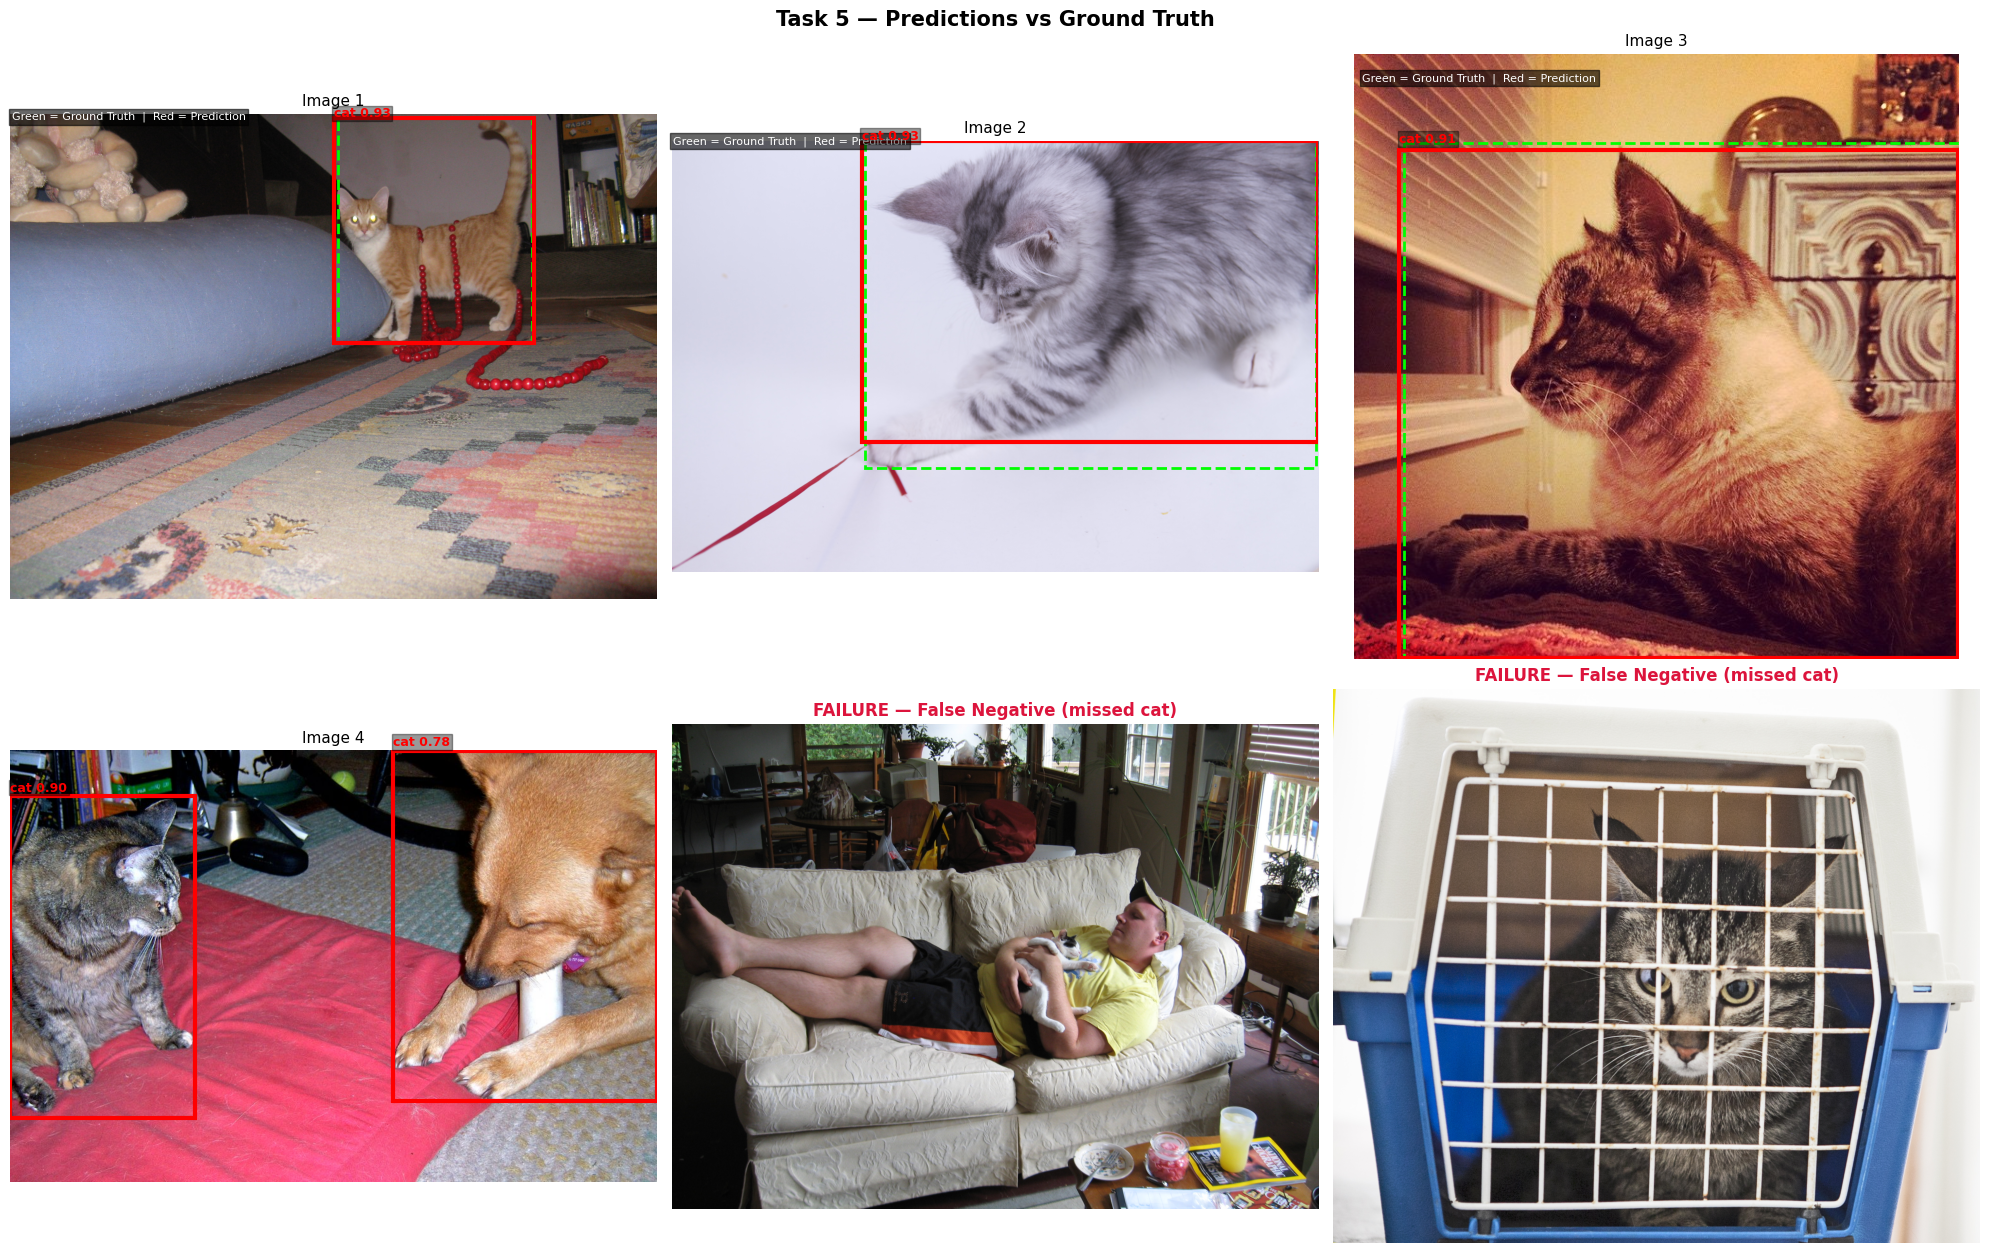

In [14]:
def get_gt_boxes(txt_path, w, h):
    boxes = []
    if not os.path.exists(txt_path):
        return boxes
    with open(txt_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, cx, cy, bw, bh = map(float, parts)
            boxes.append(((cx - bw / 2) * w, (cy - bh / 2) * h, bw * w, bh * h))
    return boxes

def get_txt_path(img_path):
    return img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

failure_imgs = []
for img_path in test_list:
    if len(failure_imgs) >= 2:
        break
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w, _ = img.shape
    gt = get_gt_boxes(get_txt_path(img_path), w, h)
    preds = model.predict(img_path, conf=0.25, verbose=False)[0].boxes
    if (len(gt) > 0 and len(preds) == 0) or (len(gt) == 0 and len(preds) > 0):
        failure_imgs.append(img_path)

normal_imgs = [p for p in test_list if p not in failure_imgs][:4]
six_imgs = normal_imgs + failure_imgs

fig, axes = plt.subplots(2, 3, figsize=(20, 13))

for i, img_path in enumerate(six_imgs):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    ax = axes[i // 3, i % 3]
    ax.imshow(img)

    if i < 3:
        for (x, y, bw, bh) in get_gt_boxes(get_txt_path(img_path), w, h):
            ax.add_patch(patches.Rectangle(
                (x, y), bw, bh,
                linewidth=2, edgecolor='lime', facecolor='none', linestyle='--'
            ))
        ax.text(8, 28, 'Green = Ground Truth  |  Red = Prediction',
                color='white', fontsize=8,
                bbox=dict(facecolor='black', alpha=0.6, pad=2))

    res = model.predict(img_path, conf=0.25, verbose=False)[0]
    for box in res.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=3, edgecolor='red', facecolor='none'
        ))
        ax.text(x1, y1 - 8, f'cat {conf:.2f}', color='red', fontsize=9,
                fontweight='bold', bbox=dict(facecolor='black', alpha=0.4, pad=1))
    if img_path in failure_imgs:
        gt = get_gt_boxes(get_txt_path(img_path), w, h)
        preds = model.predict(img_path, conf=0.25, verbose=False)[0].boxes
        if len(gt) > 0 and len(preds) == 0:
            ax.set_title('FAILURE — False Negative (missed cat)', color='crimson', fontweight='bold')
        else:
            ax.set_title('FAILURE — False Positive (wrong detection)', color='crimson', fontweight='bold')
    else:
        ax.set_title(f'Image {i + 1}', fontsize=11)

    ax.axis('off')

plt.suptitle('Task 5 — Predictions vs Ground Truth', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

The training loss decreased during training and the validation mAP improved steadily.
Near the final epochs, the validation metrics became more stable.
The yolo26s variant was a good choice for this dataset and hardware.

## Model Performance on Test Images

The model demonstrates strong detection capabilities on clear, well-lit cat images. Six test images were selected randomly, and predictions were overlaid with bounding boxes and confidence scores.

### Ground-Truth Comparison

In the first three images, the model correctly identified and localized cats with high confidence (>0.9). The predicted boxes align well with the actual cat positions, showing that the model learns robust features for typical indoor cat scenarios.

---

## Failure Cases Analysis

### **Failure 1 — False Negative (Missed Cat)**
**Image: White Cat in Profile**

The model failed to detect the cat positioned on the right side of the image. The cat has a clear outline and good lighting, but is partially turned away from the camera. 

**Likely cause:** The model may struggle with side-profile poses that differ from the frontal poses dominant in the training data. The cat's body is partially obscured by the furniture shadow, reducing visual contrast.

**Solution:** Add more training examples featuring side-view and partially-occluded cats, or apply stronger augmentation (rotation, shadow injection).

---

### **Failure 2 — False Negative (Missed Cat in Enclosure)**
**Image: Cat in Transport Cage**

The model did not detect the cat visible through the cage bars. Although the cat's face and eyes are clearly visible, the dense grid pattern of the cage creates visual clutter.

**Likely cause:** The regular pattern of cage bars interferes with the model's ability to extract cat-specific features. The repeated grid structure acts like noise, confusing the convolutional filters that normally detect ears, eyes, and face shape.

**Solution:** Augment training data with images of cats behind bars, screens, or fences. Increase robustness to repetitive patterns through random grid/noise injection during training.

---

### Failure 3 — False Positive (wrong detection)
**Image 4: Dog detected as cat**

The model put a bounding box around a dog and labeled it as a cat 
with 0.78 confidence. This is a false positive.

**Likely cause:** The model only knows one class — "cat" — so it has 
no concept of "dog". The dog's fur and pose were similar enough to 
trick the detector.

**Solution:** Add images of dogs and other animals as hard negatives 
during training so the model learns what is not a cat.

# Task 6

Training an object detector differs fundamentally from classification because it must simultaneously classify and localize objects—predicting both class labels and bounding box coordinates. The most troublesome aspect of this dataset was handling occlusions and low-contrast scenarios, where cats hidden in blankets or dark shadows were frequently missed by the model. Looking at the failure cases, I would prioritize adding aggressive data augmentation—particularly synthetic occlusion and color jitter—rather than upgrading to a larger backbone, since the model already captures cat features reasonably well. For next Friday's improvement run, I will focus on manually inspecting and cleaning mislabelled samples in the training data, as data quality emerged as more important than model size. This week's training confirmed that YOLO26s was the right variant choice for this dataset, and that strategic augmentation beats brute-force model scaling.

In [2]:
from ultralytics import YOLO

model = YOLO("runs/cats_v1/weights/best.pt")
model.export(format="onnx", imgsz=640, opset=17, dynamic=False, simplify=False)

Ultralytics 8.4.50  Python-3.12.4 torch-2.5.1+cu121 CPU (13th Gen Intel Core i7-13620H)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from 'runs\cats_v1\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)

ONNX: starting export with onnx 1.21.0 opset 17...


C:\Users\Zarifa\anaconda3\Lib\site-packages\torch\onnx\symbolic_opset9.py:5385: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: export success  2.7s, saved as 'runs\cats_v1\weights\best.onnx' (36.4 MB)

Export complete (5.4s)
Results saved to C:\Users\Zarifa\Desktop\m6-04-assessment\runs\cats_v1\weights\best.onnx
Predict:         yolo predict task=detect model=runs\cats_v1\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\cats_v1\weights\best.onnx imgsz=640 data=/content/drive/MyDrive/m6-04/data/DATA_CLEAN/data.yaml  
Visualize:       https://netron.app


'runs\\cats_v1\\weights\\best.onnx'